In [2]:
import os
import sys
import rootutils
import pandas as pd
import numpy as np

# Setup the project root indicator
root = rootutils.setup_root(search_from=os.getcwd(), indicator=".project-root", pythonpath=True)
print(f"Project root located at: {root}")

Project root located at: /Users/khickey/Desktop/lemurs/lemurs-modeling


In [3]:
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Classifiers (For Classification Sweeps) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# --- Regressors (For Regression Sweeps) ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

# --- Common Non-Sklearn Additions for Sweeps ---
# (Uncomment if needed, usually essential for a modern sweep)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
# from catboost import CatBoostClassifier, CatBoostRegressor

In [4]:
from src.utils.database_service import DatabaseService
from dotenv import load_dotenv

# Load environment variables (.env)
load_dotenv()

# Initialize and connect
db = DatabaseService()
if db.connect():
    print("Successfully connected to the database!")
    # Extract a small sample from the proximity table
    proximity_df = db.extract_from_database("proximity")
    print(f"Proximity dataframe shape: {proximity_df.shape}")
    print("\nFirst few rows of raw Proximity (Bluetooth scan) data:")
    display(proximity_df.head())
    db.disconnect()
else:
    print("Database connection failed. Check your .env file.")

Successfully connected to the database!


/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


Proximity dataframe shape: (16017, 4)

First few rows of raw Proximity (Bluetooth scan) data:


,id,app_user_id,number_of_devices,timestamp
0,1,2,38,2025-11-06 15:45:22.193
1,2,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
3,4,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344


In [5]:
def preprocess_proximity(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocesses raw Proximity (Bluetooth Scan) data.
    
    Args:
        df: Raw DataFrame from proximity table.
    Returns:
        Cleaned DataFrame satisfying the DataModule contract.
    """
    # 1. Rename 'timestamp' to 'start_timestamp' to satisfy the DataModule contract
    df = df.rename(columns={"timestamp": "start_timestamp"})
    
    # 2. Filter out invalid/negative device counts
    df = df[df["number_of_devices"] >= 0].copy()

    # 3. DO ANY OTHER DATA PROCESSING/CLEANING STEPS HERE (REMOVE DUPLICATES, IMPUTE VALUES, ETC)
    df = df.drop_duplicates(subset=['app_user_id', 'number_of_devices', 'start_timestamp'])
    
    return df

# Verify the preprocessor locally
db.connect()
raw_df = db.extract_from_database("proximity")
db.disconnect()

cleaned_df = preprocess_proximity(raw_df)
print("Columns after preprocessing:", list(cleaned_df.columns))
display(cleaned_df.head())

/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


Columns after preprocessing: ['id', 'app_user_id', 'number_of_devices', 'start_timestamp']


,id,app_user_id,number_of_devices,start_timestamp
0,1,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344
5,6,5,60,2025-11-15 10:30:31.541
6,7,5,65,2025-11-15 17:51:09.777


In [48]:
import inspect
from hydra.utils import instantiate
import hydra
from omegaconf import OmegaConf
from pathlib import Path

# look at configs/data/aggregator to select which one you want
LABEL_CHOICE = "suicide_risk"
# leave below frozen
YAML_PATH = Path(f"../configs/data/aggregator/{LABEL_CHOICE}.yaml")

# Load the config file that is the data label aggregator
cfg = OmegaConf.load(YAML_PATH)

# Instantiate the aggregator
aggregator = hydra.utils.instantiate(cfg)

from src.data.components.label_aggregators import MeanAggregator 
from src.data.components.samplers import RollingSampler, OffsetSampler
from sklearn.preprocessing import StandardScaler

# Sampler: 24-hour lookback window with hourly resampling

## can repeat the process for another scaler if want 
# SCALER_CHOICE = "subject_standard"
# SCALER_YAML_PATH = f"../configs/data/scaler/{SCALER_CHOICE}.yaml"
# scaler_cfg = OmegaConf.load(SCALER_YAML_PATH)
# sampler = hydra.utils.instantiate(scaler_cfg)

sampler = OffsetSampler(start_offset_hours=-72, end_offset_hours=0, resample_freq='1h')

# Scaler: standard scaler
scaler = StandardScaler()

In [49]:
from src.data.health_datamodule import HealthDataModule

# Register modalities, columns, and preprocessors
# Note: 'proximity' is mapped to database column 'number_of_devices'
modalities = ["proximity"]
modality_cols = {"proximity": "number_of_devices"}
preprocessors = {"proximity": preprocess_proximity}

datamodule = HealthDataModule(
    aggregator=aggregator,
    sampler=sampler,
    scaler=scaler,
    preprocessors=preprocessors,
    modalities=modalities,
    batch_size=8,
    split_mode="user",               # Disjoint populations (no user leakage between splits)
    train_val_test_split=(0.7, 0.15, 0.15),
    random_state=42
)

# Trigger setup to fetch, preprocess, split, and scale data
datamodule.setup()

print("✅ DataModule setup completed successfully!")
print(f"Train samples: {len(datamodule.data_train)}")
print(f"Val samples:   {len(datamodule.data_val)}")
print(f"Test samples:  {len(datamodule.data_test)}")

/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)
/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)
Filtering out 80 duplicate survey responses submitted within 10 minutes with identical answers.
/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please co

✅ DataModule setup completed successfully!
Train samples: 729
Val samples:   156
Test samples:  193


In [50]:
sample = next(iter(datamodule.train_dataloader()))
print(sample)

[tensor([[[ 2.1310e-04],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [ 4.0811e-02],
         [ 5.6859e-01],
         [ 1.0171e-01],
         [-1.8248e-01],
         [ 2.0321e-01],
         [ 2.1310e-04],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [ 5.4829e-01],
         [ 7.3098e-01],
         [ 8.1218e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [ 4.0811e-02],
         [-2.0086e-02],
         [-4.0385e-02],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.8248e-01],
         [-1.82

In [51]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset

def convert_to_numpy(data_source, batch_size=32):
    """Converts a DataLoader or Dataset into a tuple of numpy arrays (X, y).
    
    Automatically flattens features from [B, T, F] to [B, T*F].
    """
    # If the input is a Dataset, wrap it in a DataLoader for efficient batching
    if isinstance(data_source, Dataset):
        dataloader = DataLoader(data_source, batch_size=batch_size, shuffle=False)
    else:
        dataloader = data_source
        
    X_list = []
    y_list = []
    
    for batch in dataloader:
        x, y = batch[0], batch[1]
        
        # Convert PyTorch tensors to numpy
        if isinstance(x, torch.Tensor):
            x = x.cpu().numpy()
        if isinstance(y, torch.Tensor):
            y = y.cpu().numpy()
            
        # Ensure we have a batch dimension
        if x.ndim == 1:
            x = np.expand_dims(x, axis=0)
        if np.isscalar(y) or y.ndim == 0:
            y = np.array([y])
            
        # Flatten time/feature dimensions: [B, T, F] -> [B, T*F]
        if x.ndim > 2:
            x = x.reshape(x.shape[0], -1)
            
        X_list.append(x)
        y_list.append(y)
        
    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    
    return X_all, y_all

# Extract the training, validation, and test datasets
X_train, y_train = convert_to_numpy(datamodule.train_dataloader())
X_val, y_val = convert_to_numpy(datamodule.val_dataloader())
X_test, y_test = convert_to_numpy(datamodule.test_dataloader())


In [52]:
print(X_train.shape)
print(y_train.shape)

(729, 72)
(729,)


      Metric     Value
0   Accuracy  0.984456
1  Precision  0.000000
2     Recall  0.000000
3   F1 Score  0.000000


/Users/khickey/Desktop/lemurs/lemurs-modeling/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


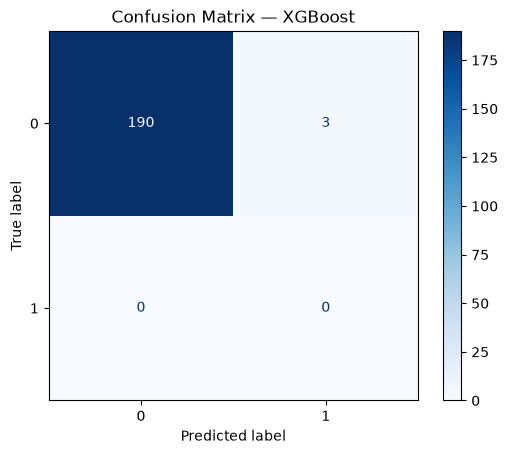

In [53]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    tree_method="hist"
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary')
rec  = recall_score(y_test, y_pred, average='binary')
f1   = f1_score(y_test, y_pred, average='binary')
cm   = confusion_matrix(y_test, y_pred)

# Display
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value":  [acc, prec, rec, f1]
})

print(results)

import matplotlib.pyplot as plt
# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix — XGBoost")
plt.show()
